## Evaluation of the Neural Additive Model (NAM) on OpenML Dataset

This notebook evaluates trained NAM models on OpenML datasets.


In [1]:
# ============================================================================
# CONFIGURATION
# ============================================================================
OPENML_DATASET_ID = 44980 # OpenML dataset ID
TASK_TYPE = "regression"  # Options: "classification" or "regression"
NUM_FOLDS = 5  # Number of folds for cross-validation
NUM_SPLITS = 20  # Number of splits per fold


In [2]:
import sys
from pathlib import Path

# Add src to path for imports
project_root = Path.cwd().parent.parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import neural_additive_models.data_utils as data_utils
import numpy as np
from utils import inverse_min_max_scaler


Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
# Load dataset
dataset_name = f"OpenML_{OPENML_DATASET_ID}_{TASK_TYPE}"
is_regression = (TASK_TYPE == "regression")

print(f"Loading dataset: {dataset_name}")
data = data_utils.load_dataset(dataset_name)
data_x, data_y, column_names = data

print(f"Dataset shape: {data_x.shape}")
print(f"Target shape: {data_y.shape}")
print(f"Number of features: {data_x.shape[1]}")
print(f"Task type: {'Regression' if is_regression else 'Classification'}")

col_min_max = {}
for i, col_name in enumerate(column_names):
    col_data = data_x[:, i]
    col_min_max[col_name] = (float(np.min(col_data)), float(np.max(col_data)))




Loading dataset: OpenML_44980_regression
Dataset shape: (8192, 8)
Target shape: (8192,)
Number of features: 8
Task type: Regression


In [4]:
from utils import create_fold_indices

fold_train_indices, fold_test_indices = create_fold_indices(
    data_x,
    data_y,
    num_folds=NUM_FOLDS,
    is_regression=is_regression,
    random_state=42
)


In [5]:
from utils import prepare_feature_arrays, get_dataset_config

# Step 1: Prepare data
SINGLE_FEATURES_ORIGINAL, UNIQUE_FEATURES_ORIGINAL, UNIQUE_FEATURES = prepare_feature_arrays(
    data_x, column_names, col_min_max, inverse_min_max_scaler
)

# Step 2: Use default config
COL_NAMES = {dataset_name: {name: name for name in column_names}}
FEATURE_LABEL_MAPPING = {dataset_name: {name: name for name in column_names}}
CATEGORICAL_NAMES = []


In [6]:
from utils import gather_nam_predictions_and_hist_data

# Set results directory
project_root = Path.cwd().parent.parent
base_logdir = project_root / 'results' / 'training' / 'nam' / f'openml_{OPENML_DATASET_ID}_{TASK_TYPE}'

all_preds_per_fold, all_hist_data, all_mean_pred = gather_nam_predictions_and_hist_data(
    fold_test_indices=fold_test_indices,
    data_x=data_x,
    column_names=column_names,
    unique_features=UNIQUE_FEATURES,
    dataset_name=dataset_name,
    base_logdir=str(base_logdir),
    num_folds=NUM_FOLDS,
    num_splits=NUM_SPLITS,
    print_every=5
)


Processing fold 1 (test set size: 1639)...
Using checkpoint: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\nam\openml_44980_regression/fold_1/split_1/model_0/best_checkpoint\model.ckpt-150
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 8
Auto-detected shallow=False from checkpoint structure
INFO:tensorflow:Restoring parameters from c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\nam\openml_44980_regression/fold_1/split_1/model_0/best_checkpoint\model.ckpt-150
✅ Restored NAM from checkpoint.
Using checkpoint: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\training\nam\openml_44980_regression/fold_1/split_2/model_0/best_checkpoint\model.ckpt-1150
Feature widths: [128, 128, 128, 128, 128, 128, 128, 128]
Num input features: 8
Auto-detected shallow=False from checkpoint structure
INFO:tensorflow:Restoring parameters from c:\Users\dejv

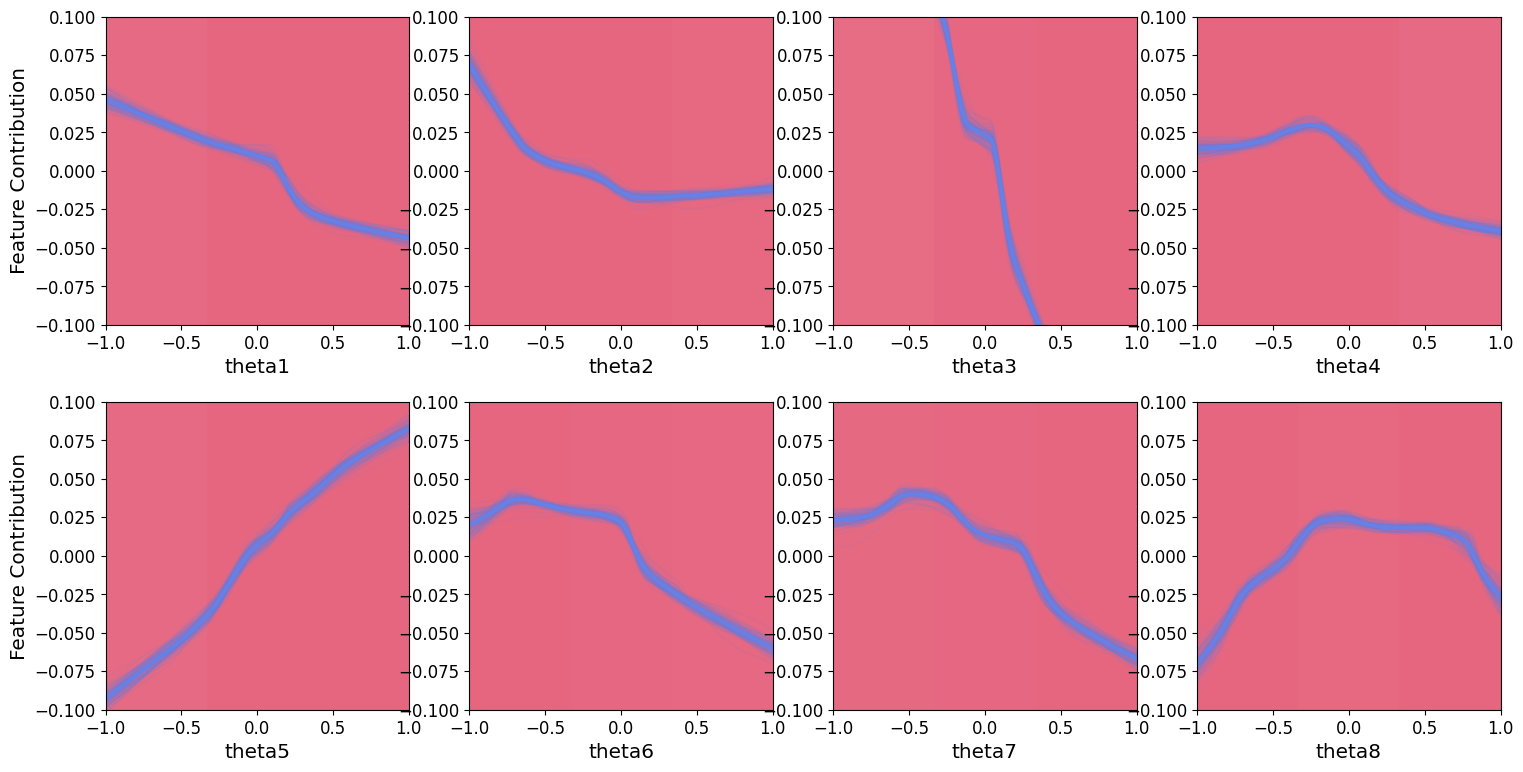

In [7]:
from utils import plot_nam_contributions_with_density

fig = plot_nam_contributions_with_density(
    hist_data=all_hist_data,
    unique_features=UNIQUE_FEATURES_ORIGINAL,
    single_features=SINGLE_FEATURES_ORIGINAL,
    categorical_names=CATEGORICAL_NAMES,
    col_mapping=COL_NAMES[dataset_name],
    feature_mapping=FEATURE_LABEL_MAPPING[dataset_name],
    mean_pred=all_mean_pred,
    feature_to_use=column_names,
    y_limits=(-0.1, 0.1)
)


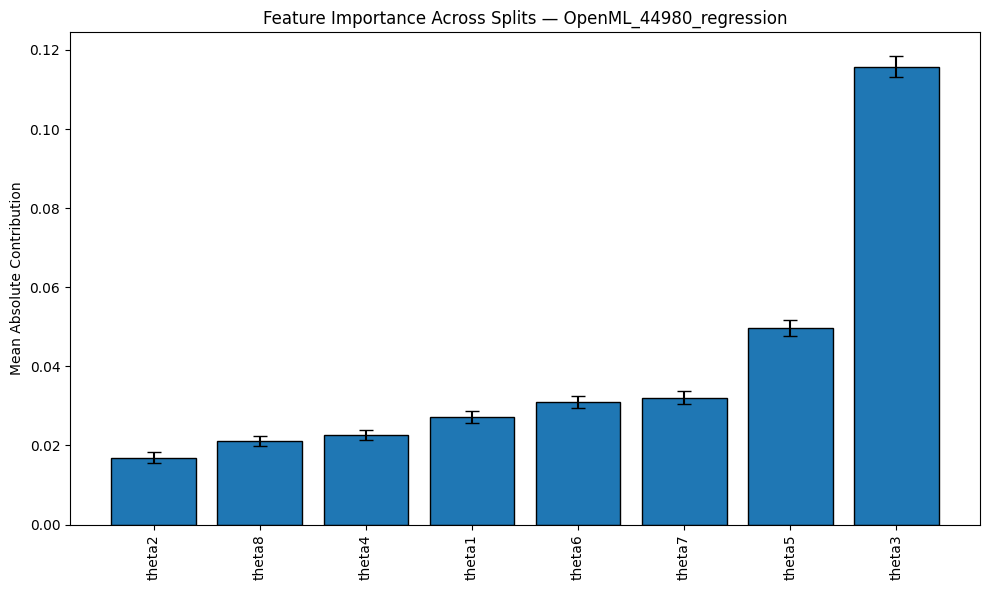

In [8]:
from utils import plot_feature_importance_across_splits

sorted_features, sorted_mean, sorted_std = plot_feature_importance_across_splits(
    all_hist_data,
    all_mean_pred,
    dataset_name
)

In [9]:
from utils import evaluate_ensemble_across_folds

fold_rmses, avg_rmse, std_rmse = evaluate_ensemble_across_folds(
    all_preds_per_fold,
    fold_test_indices,
    data_y,
    is_regression=True,
    verbose=True
)

Fold 1 RMSE (test set only): 0.2007 (n=1639)
Fold 2 RMSE (test set only): 0.1951 (n=1639)
Fold 3 RMSE (test set only): 0.1949 (n=1638)
Fold 4 RMSE (test set only): 0.1986 (n=1638)
Fold 5 RMSE (test set only): 0.2006 (n=1638)

Average Ensemble RMSE across folds (test sets only): 0.1980
Std of Ensemble RMSE across folds: 0.0026


In [10]:
from utils import save_performance_metrics

# Save detailed performance metrics for statistical analysis
output_file = save_performance_metrics(
    all_preds_per_fold=all_preds_per_fold,
    fold_test_indices=fold_test_indices,
    data_y=data_y,
    dataset_id=OPENML_DATASET_ID,
    dataset_name=dataset_name,
    task_type=TASK_TYPE,
    model_type='NAM',
    num_folds=NUM_FOLDS,
    num_splits=NUM_SPLITS,
    is_regression=is_regression,
    project_root=project_root,
    verbose=True
)



PERFORMANCE METRICS SAVED
Saved to: c:\Users\dejvi\Documents\pythonProject\neural-additive-models-xai-seminar-1\results\evaluation\nam_OpenML_44980_regression_performance.json
Summary:
  Mean RMSE: 0.1980
  Std RMSE: 0.0026
  Min RMSE: 0.1949
  Max RMSE: 0.2007
